In [1]:
import pandas as pd
import matplotlib.pyplot as plt

day_1 = pd.read_csv('../../round_data/prices_round_5_day_2.csv', delimiter=';')
day_2 = pd.read_csv('../../round_data/prices_round_5_day_3.csv', delimiter=';')
day_3 = pd.read_csv('../../round_data/prices_round_5_day_4.csv', delimiter=';')
day_2.timestamp += 1e6
day_3.timestamp += 2e6
prices = pd.concat([day_1,day_2,day_3])
product_names = list(prices['product'].unique())
price_dfs = {name:prices[prices['product']==name].reset_index(drop=True)for name in product_names}

day_1 = pd.read_csv('../../round_data/trades_round_5_day_2.csv', delimiter=';')
day_2 = pd.read_csv('../../round_data/trades_round_5_day_3.csv', delimiter=';')
day_3 = pd.read_csv('../../round_data/trades_round_5_day_4.csv', delimiter=';')
day_2.timestamp += 1e6
day_3.timestamp += 2e6
trades = pd.concat([day_1,day_2,day_3])

trades_dfs = {name:trades[trades['symbol']==name].reset_index(drop=True)for name in product_names}

In [3]:
names = [
    "Amir",
    "Ayumi",
    "Ari",
    "Anika",
    "Boris",
    "Bashir",
    "Bonnie",
    "Blue",
    "Sanjay",
    "Sami",
    "Sierra",
    "Santiago",
    "Mikhail",
    "Mina",
    "Morgan",
    "Manuel",
    "Carlos",
    "Candice",
    "Carson",
    "Cristiano"
]


In [92]:
def pnl_from_trades(name, trades_by_name, ax):
    trades = trades_by_name[name]
    trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
    pnl = trades.apply(lambda row : row['price']*row['quantity']*row['side'], axis=1).cumsum()
    ax.plot(trades.timestamp,pnl)
    ax.set_title(f"{name} : {len(trades)}")

In [93]:
croissant_traders = trades_dfs['CROISSANTS'].buyer.unique()
croissant_trades = trades_dfs['CROISSANTS']

croissant_trades_by_name = {}
for name in croissant_traders:
    croissant_trades_by_name[name] = croissant_trades[croissant_trades.apply(lambda row : ((row['buyer']==name) | (row['seller']==name)), axis=1)]
croissant_traders

array(['Caesar', 'Paris', 'Olivia', 'Camilla'], dtype=object)

In [94]:
croissant_trades

,timestamp,buyer,seller,symbol,currency,price,quantity
0,0.0,Caesar,Paris,CROISSANTS,SEASHELLS,4265.0,8
1,200.0,Paris,Caesar,CROISSANTS,SEASHELLS,4266.0,8
2,600.0,Paris,Caesar,CROISSANTS,SEASHELLS,4266.0,5
3,1600.0,Caesar,Paris,CROISSANTS,SEASHELLS,4267.0,8
4,5000.0,Caesar,Camilla,CROISSANTS,SEASHELLS,4267.0,4
...,...,...,...,...,...,...,...
2945,2998000.0,Paris,Caesar,CROISSANTS,SEASHELLS,4272.0,5
2946,2998600.0,Caesar,Paris,CROISSANTS,SEASHELLS,4272.0,6
2947,2998800.0,Caesar,Camilla,CROISSANTS,SEASHELLS,4271.0,10
2948,2999300.0,Caesar,Paris,CROISSANTS,SEASHELLS,4271.0,6


C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be

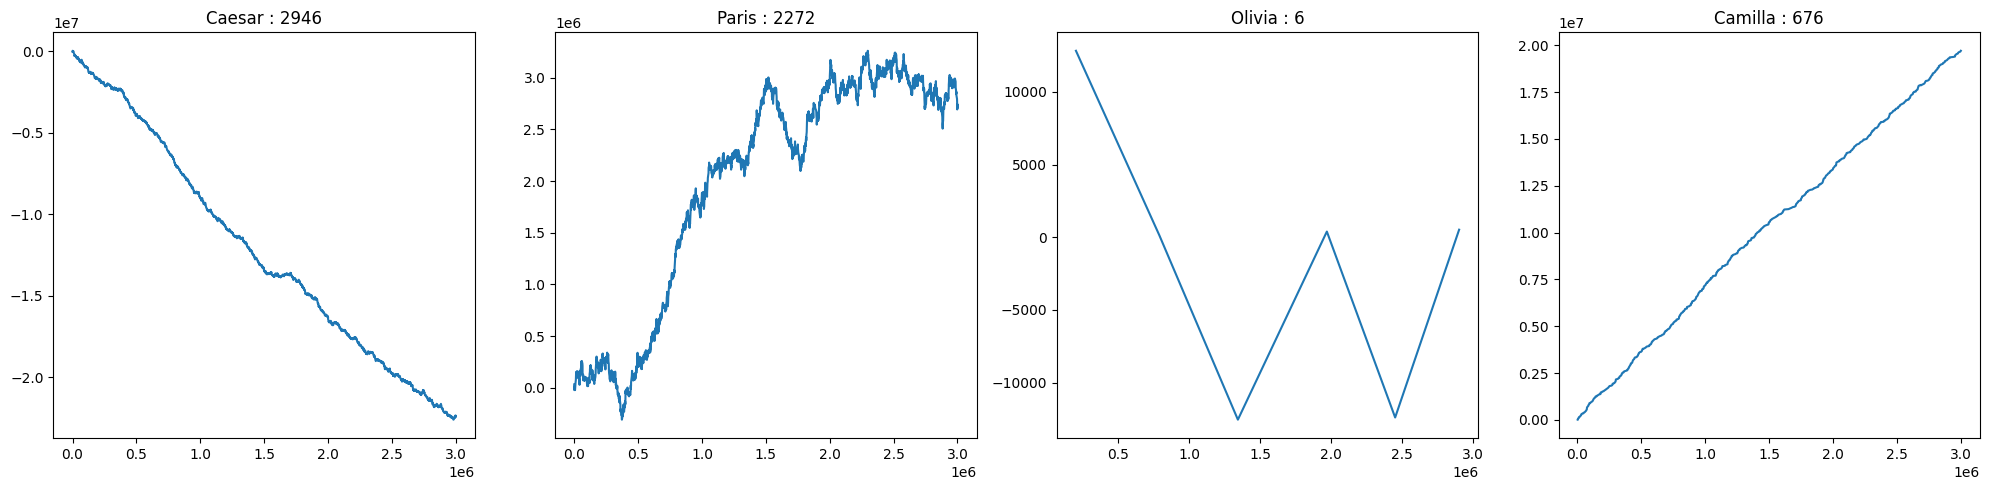

In [95]:
fig, ax = plt.subplots(ncols=len(croissant_traders),figsize=(5*len(croissant_traders),5))
for i,name in enumerate(croissant_traders):
    axis = ax[i]
    pnl_from_trades(name, croissant_trades_by_name, ax=axis)
fig.tight_layout()

In [115]:
trades = croissant_trades_by_name['Olivia']
pnl = trades.apply(lambda row : row['price']*row['quantity']*row['side'], axis=1).cumsum()
end_quantity = (-trades.side*trades.quantity).cumsum().iloc[-1]
end_price = price_dfs['CROISSANTS'].mid_price.iloc[-1]
print(pnl.iloc[-1] + end_quantity*end_price)
print(end_quantity)

525.0
0


In [66]:
jams_traders = trades_dfs['JAMS'].buyer.unique()
jams_trades = trades_dfs['JAMS']

jams_trades_by_name = {}
for name in jams_traders:
    jams_trades_by_name[name] = jams_trades[jams_trades.apply(lambda row : ((row['buyer']==name) | (row['seller']==name)), axis=1)]
jams_traders

array(['Paris', 'Caesar', 'Camilla'], dtype=object)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be

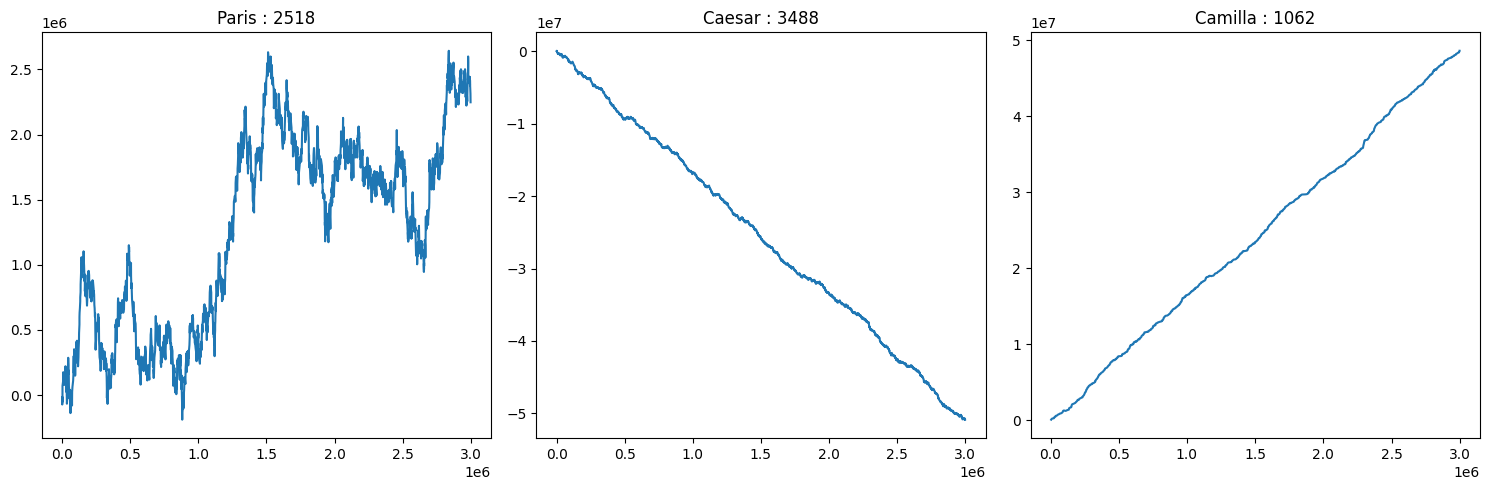

In [67]:
fig, ax = plt.subplots(ncols=len(jams_traders),figsize=(5*len(jams_traders),5))
for i,name in enumerate(jams_traders):
    axis = ax[i]
    pnl_from_trades(name, jams_trades_by_name, ax=axis)
fig.tight_layout()

In [114]:
trades = jams_trades_by_name['Paris']
pnl = trades.apply(lambda row : row['price']*row['quantity']*row['side'], axis=1).cumsum()
end_quantity = (-trades.side*trades.quantity).cumsum().iloc[-1]
end_price = price_dfs['JAMS'].mid_price.iloc[-1]
print(pnl.iloc[-1] + end_quantity*end_price)
print(end_quantity)

-4144.0
-346


In [68]:
djembes_traders = trades_dfs['DJEMBES'].buyer.unique()
djembes_trades = trades_dfs['DJEMBES']

djembes_trades_by_name = {}
for name in djembes_traders:
    djembes_trades_by_name[name] = djembes_trades[djembes_trades.apply(lambda row : ((row['buyer']==name) | (row['seller']==name)), axis=1)]
djembes_traders

array(['Paris', 'Caesar', 'Camilla'], dtype=object)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be

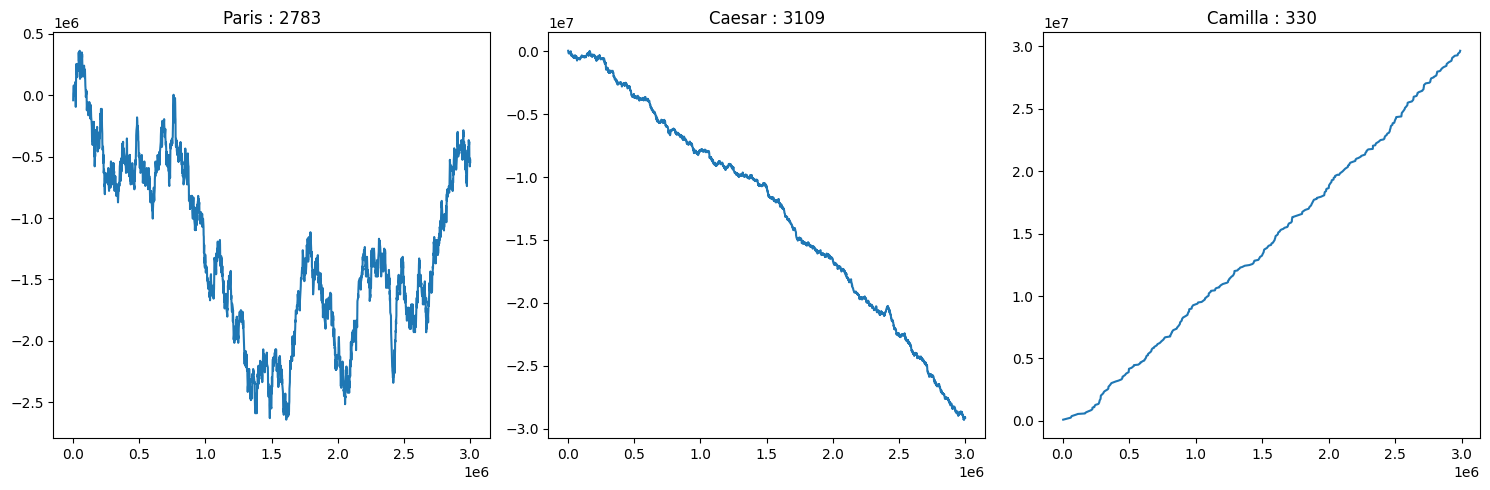

In [69]:
fig, ax = plt.subplots(ncols=len(djembes_traders),figsize=(5*len(djembes_traders),5))
for i,name in enumerate(djembes_traders):
    axis = ax[i]
    pnl_from_trades(name, djembes_trades_by_name, ax=axis)
fig.tight_layout()

In [113]:
trades = djembes_trades_by_name['Camilla']
pnl = trades.apply(lambda row : row['price']*row['quantity']*row['side'], axis=1).cumsum()
end_quantity = (-trades.side*trades.quantity).cumsum().iloc[-1]
end_price = price_dfs['DJEMBES'].mid_price.iloc[-1]
print(pnl.iloc[-1] + end_quantity*end_price)
print(end_quantity)

-161632.5
-2223


In [70]:
picnic_1_traders = trades_dfs['PICNIC_BASKET1'].buyer.unique()
picnic_1_trades = trades_dfs['PICNIC_BASKET1']

picnic_1_trades_by_name = {}
for name in picnic_1_traders:
    picnic_1_trades_by_name[name] = picnic_1_trades[picnic_1_trades.apply(lambda row : ((row['buyer']==name) | (row['seller']==name)), axis=1)]
picnic_1_traders

array(['Pablo', 'Caesar', 'Camilla', 'Penelope', 'Charlie'], dtype=object)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)


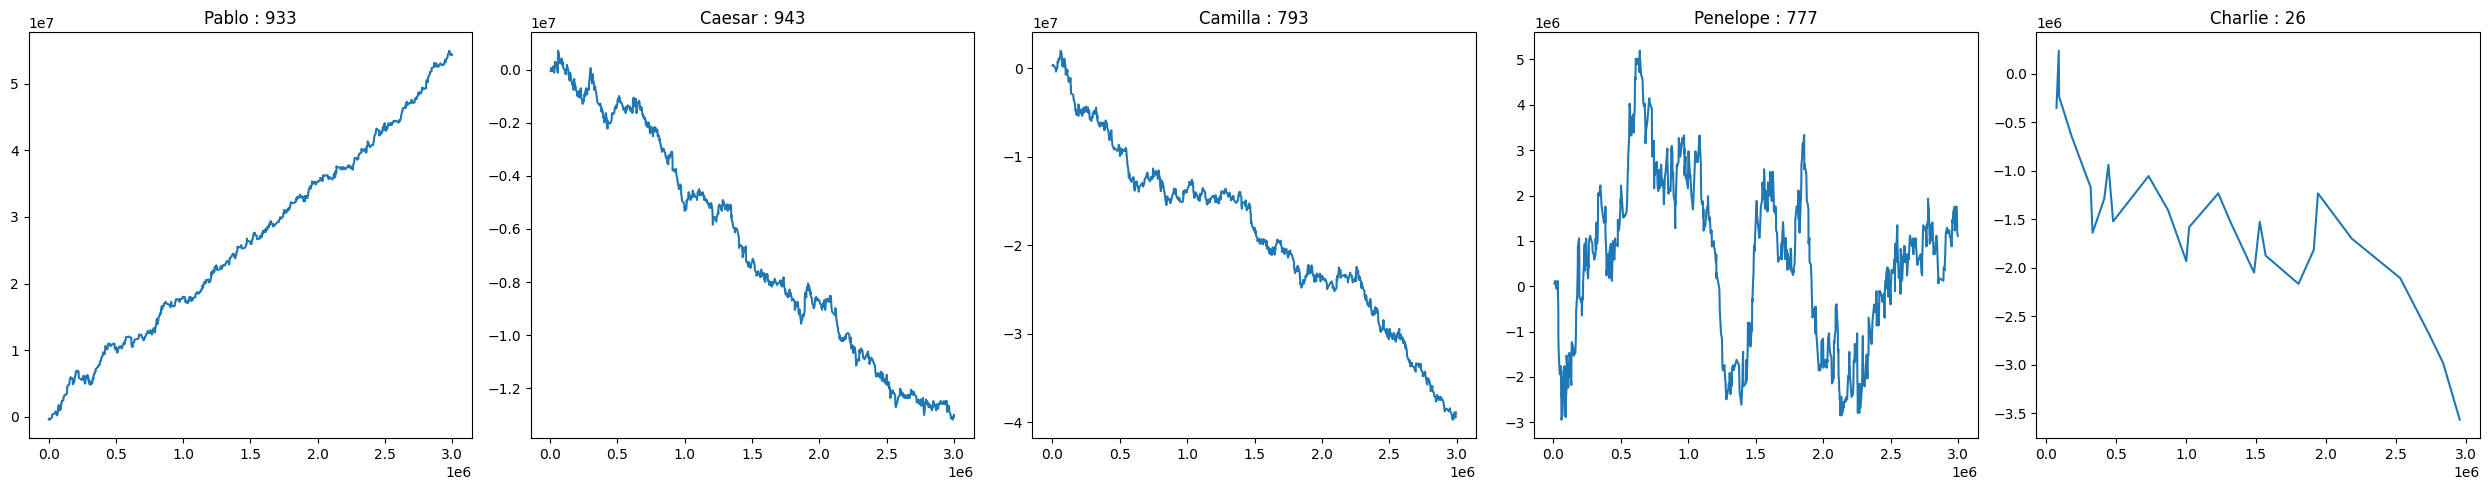

In [72]:
fig, ax = plt.subplots(ncols=len(picnic_1_traders),figsize=(5*len(picnic_1_traders),5))
for i,name in enumerate(picnic_1_traders):
    axis = ax[i]
    pnl_from_trades(name, picnic_1_trades_by_name, ax=axis)
fig.tight_layout()

In [121]:
trades = picnic_1_trades_by_name['Pablo']
pnl = trades.apply(lambda row : row['price']*row['quantity']*row['side'], axis=1).cumsum()
end_quantity = (-trades.side*trades.quantity).cumsum().iloc[-1]
end_price = price_dfs['PICNIC_BASKET1'].mid_price.iloc[-1]
print(pnl.iloc[-1] + end_quantity*end_price)
print(end_quantity)

-80477.5
-931


In [51]:
picnic_2_traders = trades_dfs['PICNIC_BASKET2'].buyer.unique()
picnic_2_trades = trades_dfs['PICNIC_BASKET2']

picnic_2_trades_by_name = {}
for name in picnic_2_traders:
    picnic_2_trades_by_name[name] = picnic_2_trades[picnic_2_trades.apply(lambda row : ((row['buyer']==name) | (row['seller']==name)), axis=1)]
picnic_2_traders

array(['Pablo', 'Camilla', 'Caesar', 'Penelope', 'Charlie'], dtype=object)

In [96]:
picnic_2_trades

,timestamp,buyer,seller,symbol,currency,price,quantity
0,1300.0,Pablo,Camilla,PICNIC_BASKET2,SEASHELLS,30114.0,6
1,5700.0,Camilla,Pablo,PICNIC_BASKET2,SEASHELLS,30091.0,2
2,8900.0,Pablo,Camilla,PICNIC_BASKET2,SEASHELLS,30105.0,3
3,9100.0,Camilla,Penelope,PICNIC_BASKET2,SEASHELLS,30099.0,9
4,13200.0,Caesar,Penelope,PICNIC_BASKET2,SEASHELLS,30098.0,1
...,...,...,...,...,...,...,...
1605,2991300.0,Camilla,Pablo,PICNIC_BASKET2,SEASHELLS,30415.0,1
1606,2995000.0,Penelope,Charlie,PICNIC_BASKET2,SEASHELLS,30405.0,10
1607,2995200.0,Caesar,Pablo,PICNIC_BASKET2,SEASHELLS,30397.0,1
1608,2996800.0,Camilla,Caesar,PICNIC_BASKET2,SEASHELLS,30414.0,1


C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)


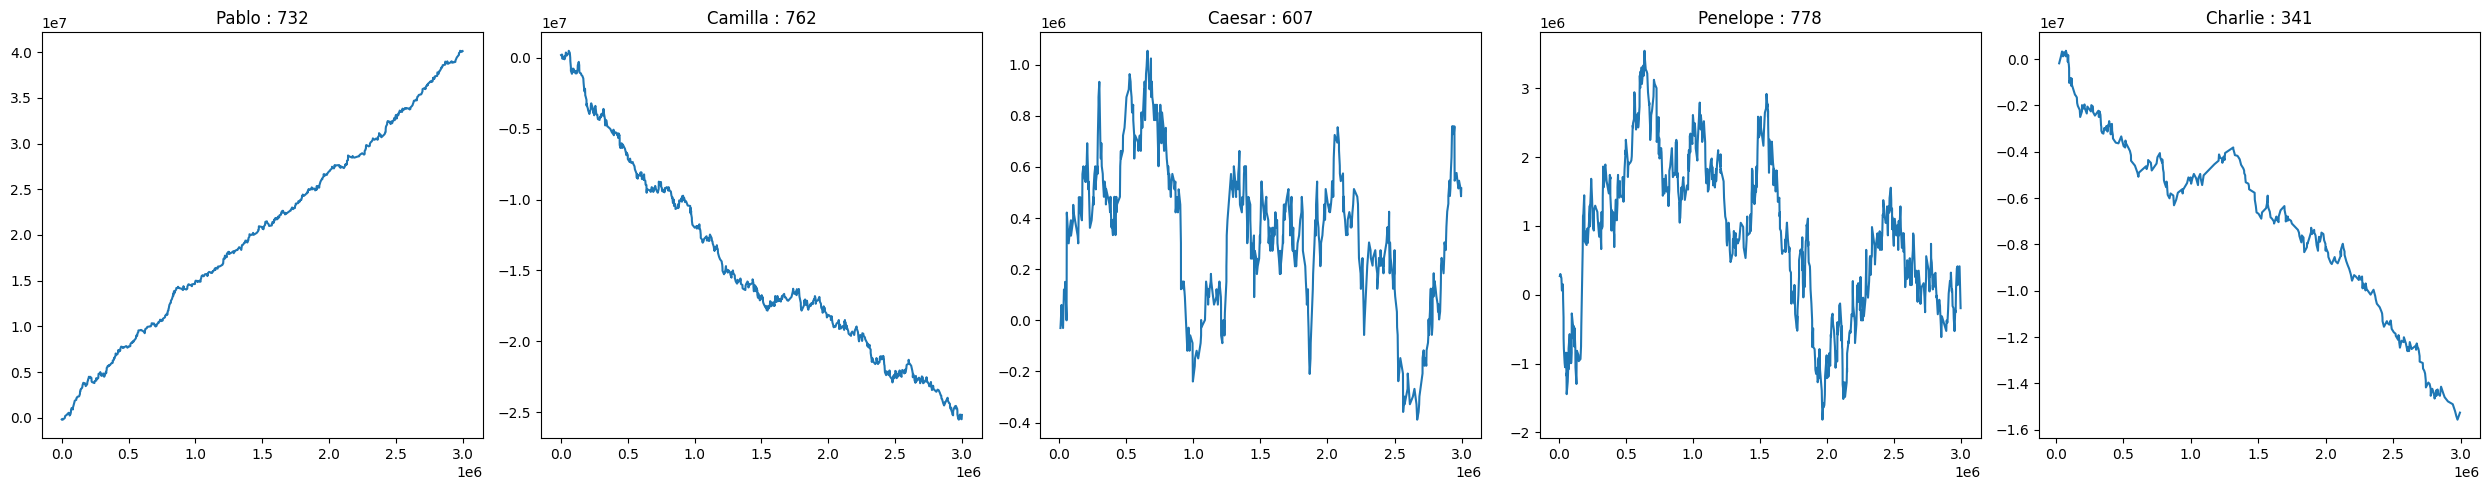

In [74]:
fig, ax = plt.subplots(ncols=len(picnic_2_traders),figsize=(5*len(picnic_2_traders),5))
for i,name in enumerate(picnic_2_traders):
    axis = ax[i]
    pnl_from_trades(name, picnic_2_trades_by_name, ax=axis)
fig.tight_layout()

In [125]:
trades = picnic_2_trades_by_name['Pablo']
pnl = trades.apply(lambda row : row['price']*row['quantity']*row['side'], axis=1).cumsum()
end_quantity = (-trades.side*trades.quantity).cumsum().iloc[-1]
end_price = price_dfs['PICNIC_BASKET2'].mid_price.iloc[-1]
print(pnl.iloc[-1] + end_quantity*end_price)
print(end_quantity)

-377091.5
-1333


In [75]:
squid_traders = trades_dfs['SQUID_INK'].buyer.unique()
squid_trades = trades_dfs['SQUID_INK']

squid_trades_by_name = {}
for name in squid_traders:
    squid_trades_by_name[name] = squid_trades[squid_trades.apply(lambda row : ((row['buyer']==name) | (row['seller']==name)), axis=1)]
squid_traders

array(['Paris', 'Charlie', 'Camilla', 'Penelope', 'Gary', 'Pablo',
       'Caesar', 'Gina', 'Olivia'], dtype=object)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be

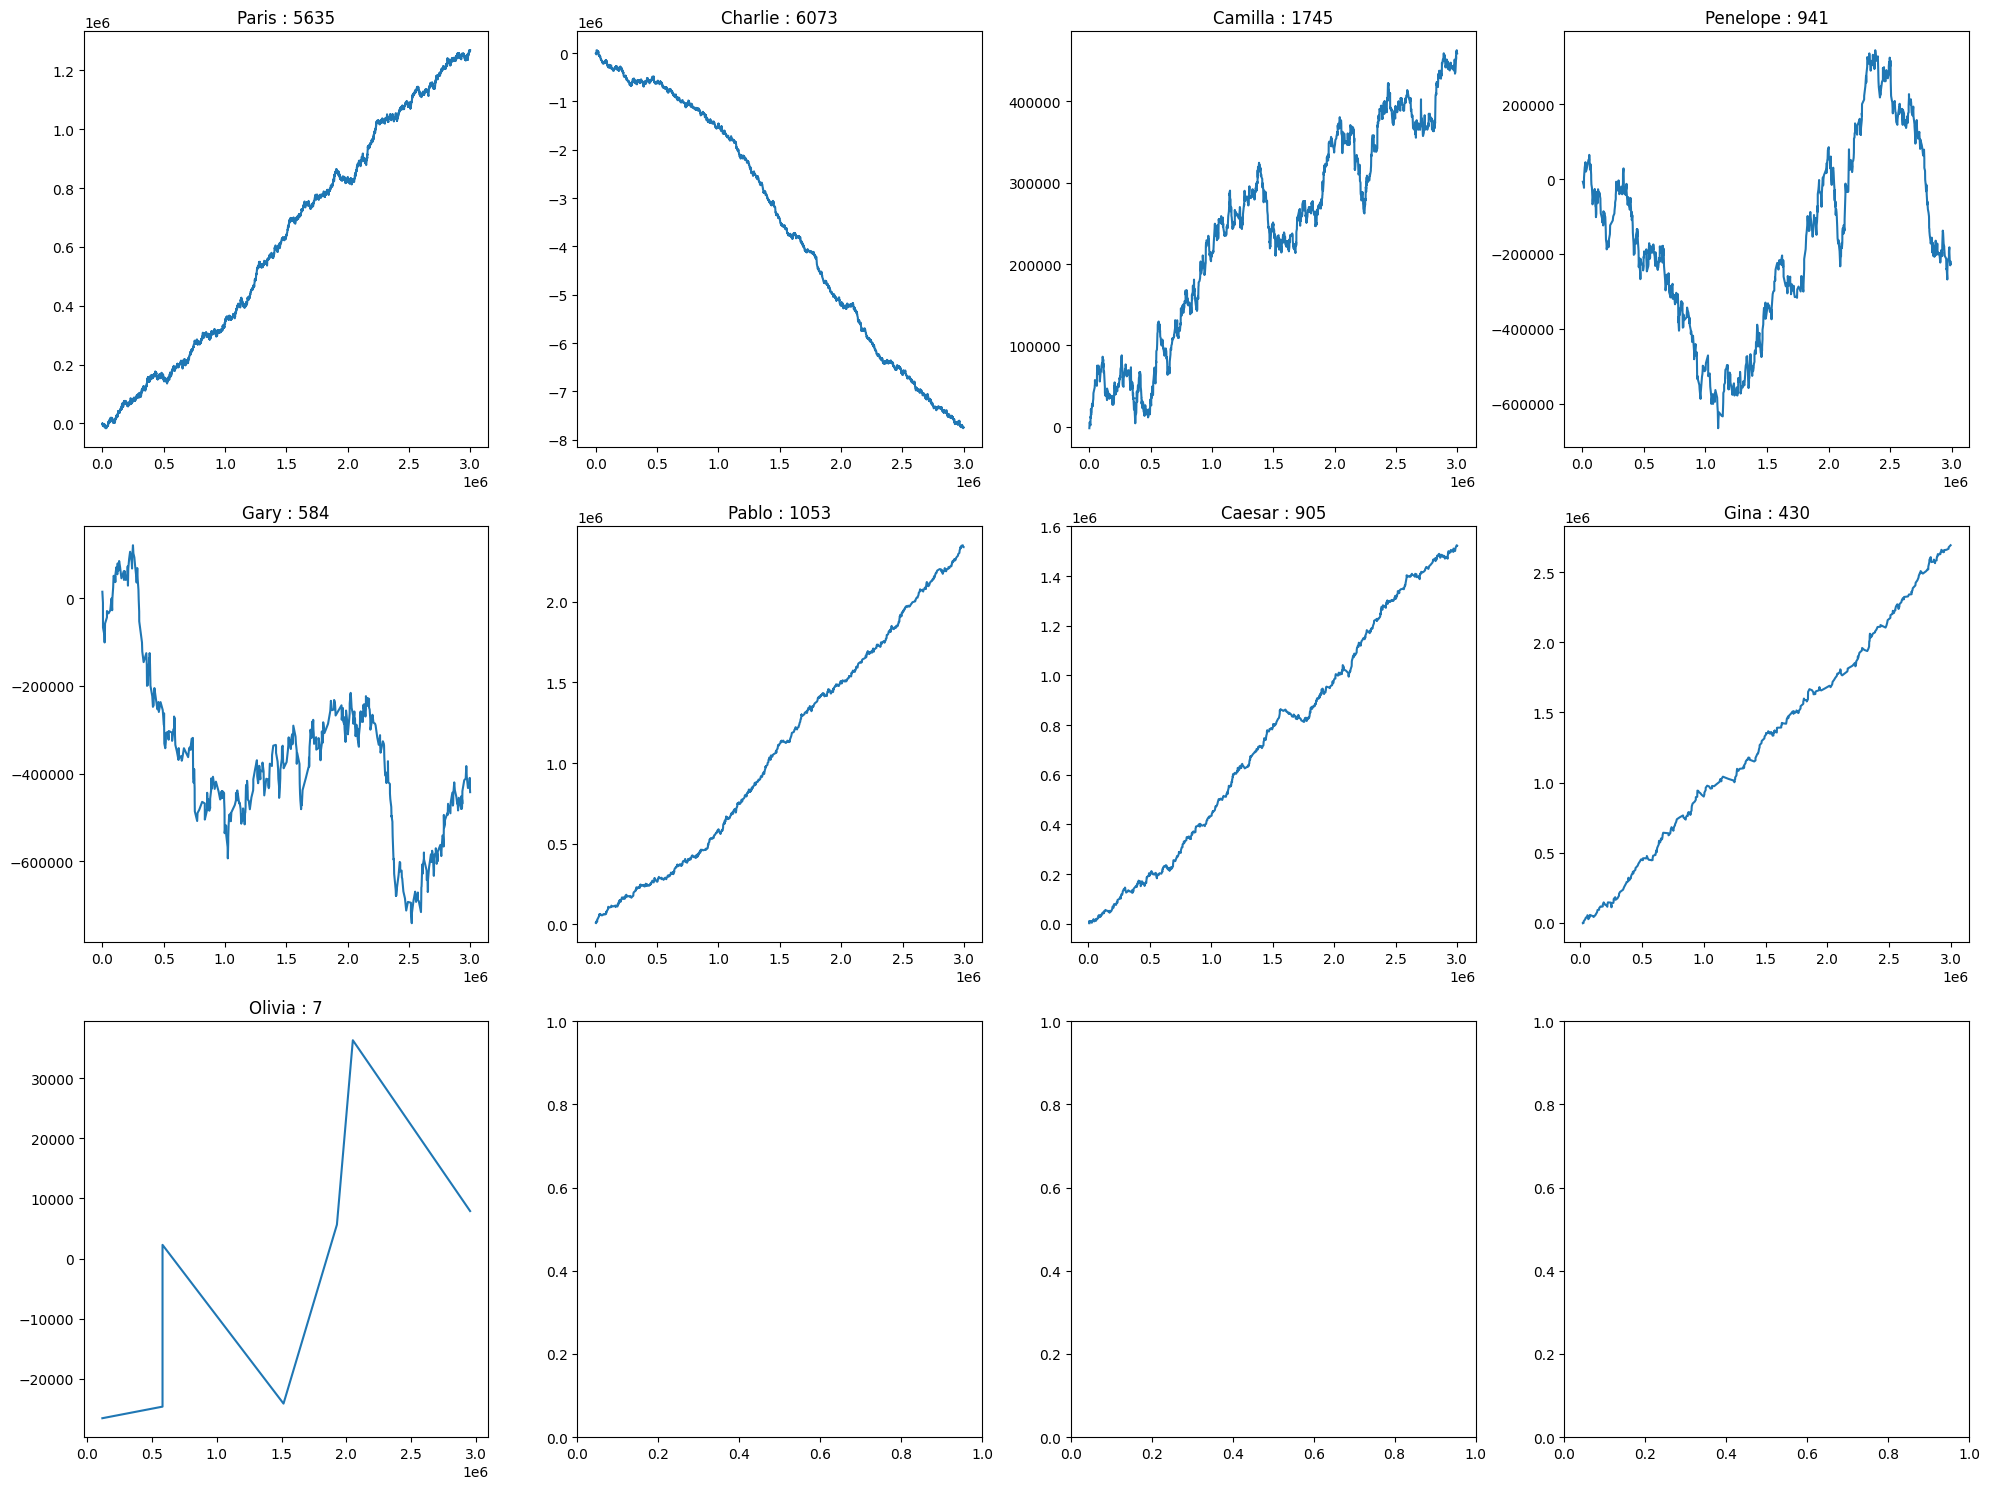

In [76]:
fig, ax = plt.subplots(ncols=4,nrows=3,figsize=(20,15))
for i,name in enumerate(squid_traders):
    col = i%4
    row = i//4
    axis = ax[row,col]
    pnl_from_trades(name, squid_trades_by_name, ax=axis)
fig.tight_layout()

In [127]:
trades = squid_trades_by_name['Gina']
pnl = trades.apply(lambda row : row['price']*row['quantity']*row['side'], axis=1).cumsum()
end_quantity = (-trades.side*trades.quantity).cumsum().iloc[-1]
end_price = price_dfs['SQUID_INK'].mid_price.iloc[-1]
print(pnl.iloc[-1] + end_quantity*end_price)
print(end_quantity)

-23879.5
-1431


In [77]:
rock_traders = trades_dfs['VOLCANIC_ROCK'].buyer.unique()
rock_trades = trades_dfs['VOLCANIC_ROCK']

rock_trades_by_name = {}
for name in rock_traders:
    rock_trades_by_name[name] = rock_trades[rock_trades.apply(lambda row : ((row['buyer']==name) | (row['seller']==name)), axis=1)]
rock_traders

array(['Caesar', 'Pablo', 'Peter'], dtype=object)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)


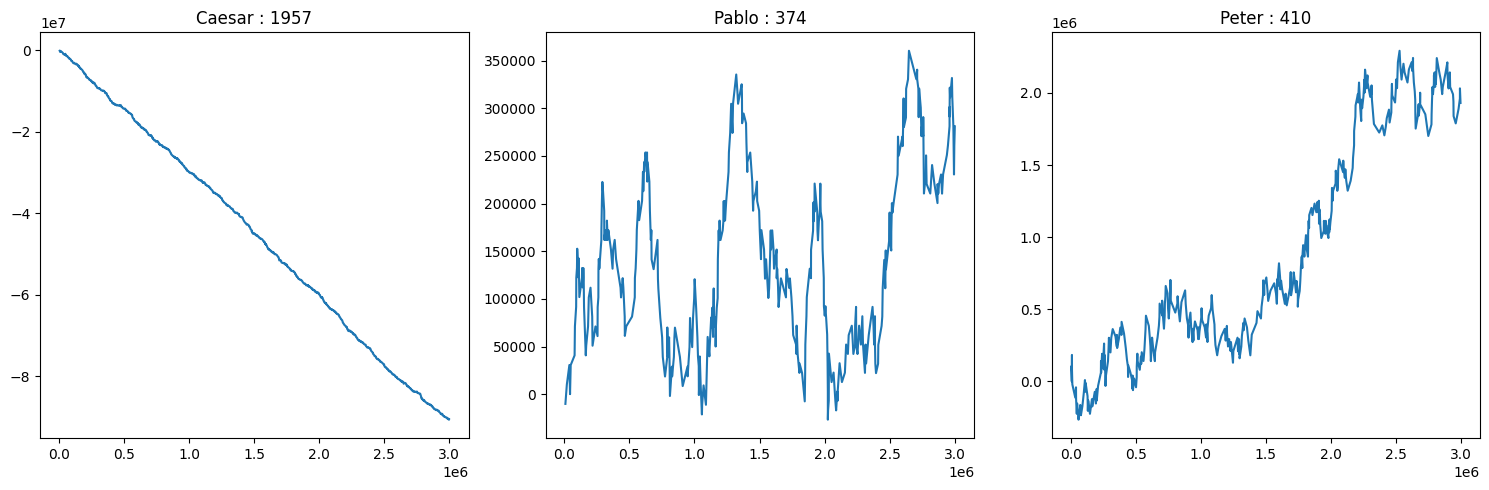

In [78]:
fig, ax = plt.subplots(ncols=len(rock_traders),figsize=(5*len(rock_traders),5))
for i,name in enumerate(rock_traders):
    axis = ax[i]
    pnl_from_trades(name, rock_trades_by_name, ax=axis)
fig.tight_layout()

In [81]:
macarons_traders = trades_dfs['MAGNIFICENT_MACARONS'].buyer.unique()
macarons_trades = trades_dfs['MAGNIFICENT_MACARONS']

macarons_trades_by_name = {}
for name in macarons_traders:
    macarons_trades_by_name[name] = macarons_trades[macarons_trades.apply(lambda row : ((row['buyer']==name) | (row['seller']==name)), axis=1)]
macarons_traders

array(['Caesar', 'Paris', 'Camilla', 'Charlie'], dtype=object)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['side'] = trades.apply(lambda row : -1 if row['buyer']==name else 1, axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_43888\1133987768.py:3: SettingWithCopyWarning: 
A value is trying to be

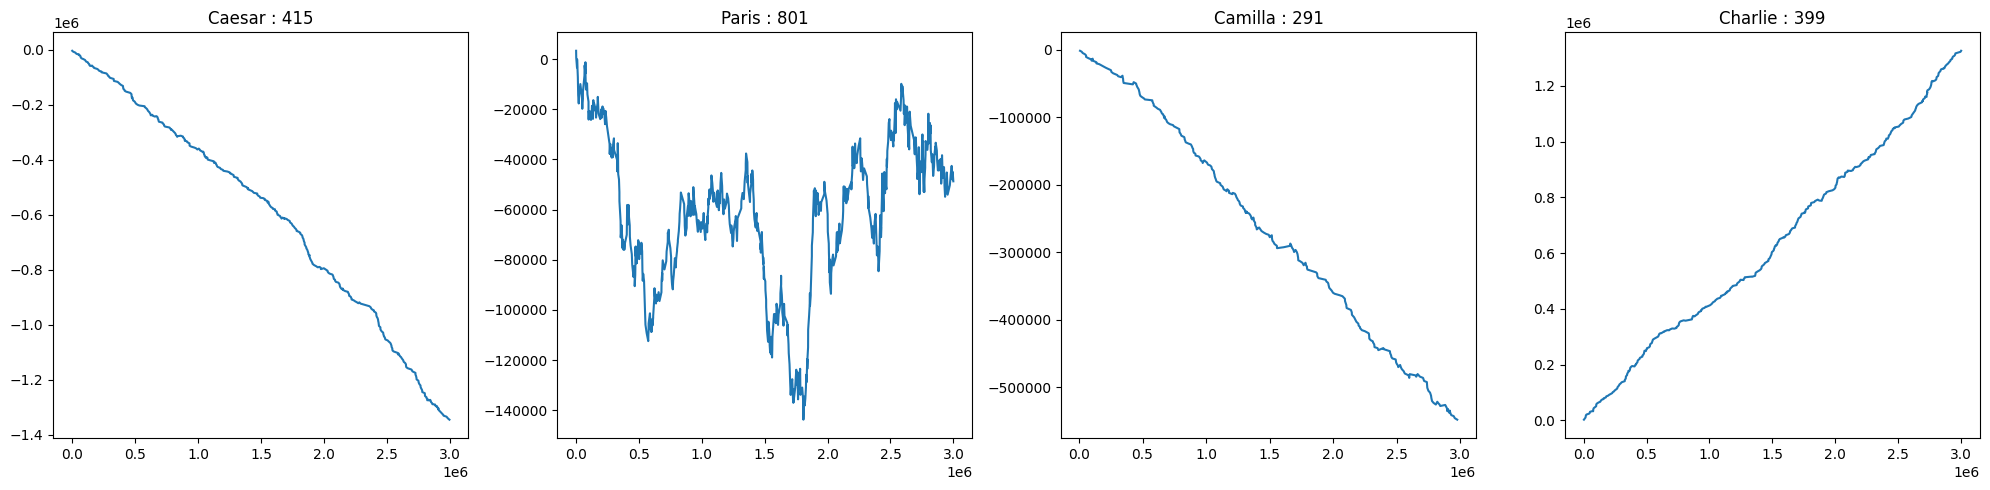

In [82]:
fig, ax = plt.subplots(ncols=len(macarons_traders),figsize=(5*len(macarons_traders),5))
for i,name in enumerate(macarons_traders):
    axis = ax[i]
    pnl_from_trades(name, macarons_trades_by_name, ax=axis)
fig.tight_layout()